# 💖 Tinder Strategy: Decoding Match Dynamics

Analysis of 4,000+ interactions proving that while users search for depth on paper, attraction is governed by a non-linear attractiveness threshold and a significant self-perception bias.

📌 **Business Stakes & Analysis Objectives**  
In a market characterized by declining engagement rates (matches), Tinder seeks to identify the true drivers of mutual attraction. The goal of this analysis is to decode the mechanisms influencing user decision-making to optimize algorithmic performance and user satisfaction.

**The Dataset at a Glance:**
- *Volume*: $4,189$ unique romantic interactions ($8,378$ observations).
- *Sample*: 551 profiles with diverse socio-demographic characteristics.
- *Depth*: Nearly 200 indicators measuring expectations, self-perception, and partner ratings.
- *Period*: Experimental study conducted over 21 events.

**🛠️ Analytical Journey**
This project goes beyond basic statistics; it follows a rigorous data validation process to ensure reliable strategic recommendations:

1. 📊 Diagnostic & Visualization
Immersing into the data to extract major trends. We identify the first signals that explain the success or failure of an encounter, specifically looking at the hierarchy of global desires.

2. 🛡️ Integrity Audit & Reliability (Critical Analysis)
Testing hypotheses through a rigorous data lens. This crucial step analyzes the consistency between what users state (self-evaluation) and the perceived reality (partner judgment). We measure the accuracy and subjectivity of ratings to identify self-perception biases.

3. 🎯 Strategic Synthesis: The "Say vs. Do" Paradox
Translating mathematical results into actionable business levers. The core of this analysis highlights the critical gap between Stated Preferences (SAY)—like intelligence or sincerity—and Revealed Preferences (DO), where physical attractiveness acts as the primary gatekeeper.

💡 Methodological Note: Raw data without internal consistency checks is merely intuition. This notebook focuses on confronting individual perceptions with the statistical reality of the group to produce a robust, evidence-based analysis.

## **1. Setup & Dependencies**
* **Data Manipulation**: `pandas` & `numpy`
* **Visualization**: `seaborn`, `matplotlib`, and `plotly`
* **Utility**: `chardet` for encoding detection and `warnings` for output management.

In [80]:
# Standard Libraries
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Visual Style Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# The liberary detects the encoding code if our file is encoded! ("utf-8", "latin-1", "sp1252") etc...
import chardet

# Configuration to suppress unnecessary warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

print("=" * 35)
print("Environment Setup Complete ...")
print("=" * 35)

Environment Setup Complete ...


## **2. Data Acquisition & Initial Inspection**
- In this section, we programmatically detect the file encoding to ensure data integrity during the loading process.  
- We then perform a high-level inspection to understand the dataset's dimensions and the number of unique participants involved in the study.

In [81]:
# 1. Encoding Detection
result = chardet.detect(open("Speed+Dating+Data.csv", "rb").read())
print(f"Detected Encoding: {result}")

Detected Encoding: {'encoding': 'Windows-1252', 'confidence': 0.7292458070575607, 'language': ''}


In [82]:
# 2. Data loading
# Using the detected encoding
df = pd.read_csv('Speed+Dating+Data.csv', encoding=result["encoding"])

# 3. Execution Summary
print(f"\n{'='*31}")
print("👉 Dataset preview")
print('='*31)
print(f"Total observtions       : {df.shape[0]:,}")
print(f"Variables               : {df.shape[1]}")
print(f"Uniques participants    : {df['iid'].nunique()}")
print(f"Waves (events)          : {df['wave'].nunique()}")
print('='*31)


👉 Dataset preview
Total observtions       : 8,378
Variables               : 195
Uniques participants    : 551
Waves (events)          : 21


In [83]:
# 4. First look at the data
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


## **3. 🕵️‍♂️ Data Quality Audit**
Before diving into analysis, we perform a deep-dive audit of the 195 variables. This custom **Dynamic Data Dictionary** allows us to:
* **Integrity Check**: Spot inconsistencies in unique values (e.g., categorical formatting).
* **Missingness Analysis**: Identify features with high nullity rates to inform our filtering strategy.

In [84]:
# Create a custom Data Quality Summary for our clean DataFrame 
summary_df = pd.DataFrame({
    # 1. Column Name
    "variable": df.columns,
    
    # 2. Data Type check
    "python_type": df.dtypes.values,
    
    # 3. List of unique values
    "unique_values": [df[col].unique() for col in df.columns],

    # 4. Min value
    "min_value": [df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None for col in df.columns],
    
    # 5. Max value
    "max_value": [df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None for col in df.columns],

    # 6. Count of unique values
    "unique_count": [df[col].nunique() for col in df.columns],

    # 7. Counting Missing Values
    "missing_values": [df[col].isna().sum() for col in df.columns], 
    
    # 8. Percentage of missing values
    "missing_%": [round(df[col].isna().mul(100).mean(), 2) for col in df.columns]
})

# Displaying all rows in my summary
with pd.option_context("display.max_rows", None):
    display(summary_df)

,variable,python_type,unique_values,min_value,max_value,unique_count,missing_values,missing_%
0,iid,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.00,552.00,551,0,0.00
1,id,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",1.00,22.00,22,1,0.01
2,gender,int64,"[0, 1]",0.00,1.00,2,0,0.00
3,idg,int64,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 2, 4, 6, 8...",1.00,44.00,44,0,0.00
4,condtn,int64,"[1, 2]",1.00,2.00,2,0,0.00
5,wave,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.00,21.00,21,0,0.00
6,round,int64,"[10, 16, 19, 18, 5, 20, 9, 21, 14, 8, 6, 11, 1...",5.00,22.00,15,0,0.00
7,position,int64,"[7, 3, 9, 6, 4, 8, 5, 10, 1, 2, 12, 13, 15, 18...",1.00,22.00,22,0,0.00
8,positin1,float64,"[nan, 2.0, 3.0, 4.0, 1.0, 5.0, 9.0, 10.0, 13.0...",1.00,22.00,22,1846,22.03
9,order,int64,"[4, 3, 10, 5, 7, 6, 1, 2, 8, 9, 11, 15, 12, 16...",1.00,22.00,22,0,0.00


### Data Type Distribution
- To define our preprocessing strategy, we analyze the distribution of data types. 
- The dominance of numerical variables (over 95% combining float and int) suggests that the dataset is primarily composed of quantitative ratings, making it ideal for correlation-based analysis.

In [85]:
data_type = pd.DataFrame({
    "num_columns" : summary_df["python_type"].value_counts(), # Gives us a df of two columns [0] the python_type values, [1] the count.
    "percentage %" : summary_df["python_type"].value_counts(normalize=True).mul(100).round(2).astype(str)+" %"
}).reset_index().rename(columns={"python_type" : "data_types"})
data_type

,data_types,num_columns,percentage %
0,float64,174,89.23 %
1,int64,13,6.67 %
2,object,8,4.1 %


## **4. Cleaning & preparations**
- 4.1. Feature Selection & Missing data Strategy (Le drop des 15%)
- 4.2. Post-Filtering Data Quality Audit (L'audit du df_clean)
- 4.3. Data Integrity & Relational Repair (IDs, Vague 5, Age, Race)
- 4.4. Feature Engineering: Categorical Mapping
- 4.5. Statistical Pre-Aggregation (df_gap & df_plot)

In [86]:
# Having a copy of our raw data
df_copy = df.copy()

### 4.1. Feature Selection & Missing Data Strategy
With 195 initial variables, the dataset contains significant noise and sparsity. My cleaning strategy following two main rules:

1. **Statistical Reliability**: I am dropping every column with more than **15% missing values**. Beyond this threshold, data imputation (filling gaps) introduces too much statistical bias, potentially compromising the integrity of our findings.
2. **Contextual Relevance**: By removing sparse features, we reduce dimensionality to focus exclusively on the core attributes required for our "Say vs. Do" and self-perception analysis.

In [87]:
print("=" * 63)
# Initial dimensions
df_copy_index, df_copy_columns = len(df_copy), len(df_copy.columns)
print(f"Original Dataset: {df_copy_index} rows | {df_copy_columns} columns")
print("=" * 35)

# Identifying sparse features
# Filtring the summary_df and getting the 'Variable' column in a list form
col_to_drop_15 = summary_df.loc[(summary_df["missing_values"] / len(df_copy)) >= 0.15, "variable"].tolist()
print(f"Sparsity Alert: {len(col_to_drop_15)} features selected for removal (>15% missing)")
print("=" * 35)
print(f"Features to be dropped {col_to_drop_15}")
print("=" * 35)

# Execution
df_clean = df_copy.drop(columns=col_to_drop_15)

# Verification
df_clean_index, df_clean_columns = len(df_clean), len(df_clean.columns)
print(f"Cleaned Dataset: {df_clean_index} rows | {df_clean_columns} columns")
print("=" * 63)

Original Dataset: 8378 rows | 195 columns
Sparsity Alert: 90 features selected for removal (>15% missing)
Features to be dropped ['positin1', 'undergra', 'mn_sat', 'tuition', 'income', 'expnum', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s', 'attr3_s', 'sinc3_s', 'intel3_s', 'fun3_s', 'amb3_s', 'attr7_2', 'sinc7_2', 'intel7_2', 'fun7_2', 'amb7_2', 'shar7_2', 'attr4_2', 'sinc4_2', 'intel4_2', 'fun4_2', 'amb4_2', 'shar4_2', 'attr2_2', 'sinc2_2', 'intel2_2', 'fun2_2', 'amb2_2', 'shar2_2', 'attr5_2', 'sinc5_2', 'intel5_2', 'fun5_2', 'amb5_2', 'you_call', 'them_cal', 'date_3', 'numdat_3', 'num_in_3', 'attr1_3', 'sinc1_3', 'intel1_3', 'fun1_3', 'amb1_3', 'shar1_3', 'attr7_3', 'sinc7_3', 'intel7_3', 'fun7_3', 'amb7_3', 'shar7_3', 'attr4_3', 'sinc4_3', 'intel4_3', 'fun4_3', 'amb4_3', 'shar4_3', 'attr2_3', 'sinc2_3', 'intel2_3', 'fun2_3', 'amb2_3', 'shar2_3', 

### 4.2. 🕵️‍♂️ Data Quality Audit for the df_clean
Before diving into analysis, we perform a deep-dive audit of the 105 variables.

In [88]:
# Create a custom Data Quality Summary for our clean DataFrame 
summary_df_clean = pd.DataFrame({
    # 1. Column Name
    "variable": df_clean.columns,
    
    # 2. Data Type check
    "python_type": df_clean.dtypes.values,
    
    # 3. List of unique values
    "unique_values": [df_clean[col].unique() for col in df_clean.columns],

    # 4. Min value
    "min_value": [df_clean[col].min() if pd.api.types.is_numeric_dtype(df_clean[col]) else None for col in df_clean.columns],
    
    # 5. Max value
    "max_value": [df_clean[col].max() if pd.api.types.is_numeric_dtype(df_clean[col]) else None for col in df_clean.columns],

    # 6. Count of unique values
    "unique_count": [df_clean[col].nunique() for col in df_clean.columns],

    # 7. Counting Missing Values
    "missing_values": [df_clean[col].isna().sum() for col in df_clean.columns], 
    
    # 8. Percentage of missing values
    "missing_%": [round(df_clean[col].isna().mul(100).mean(), 2) for col in df_clean.columns]
})

print("Audit df_clean done ...")

Audit df_clean done ...


In [89]:
data_type = pd.DataFrame({
    "num_columns" : summary_df_clean["python_type"].value_counts(), # Gives us a df of two columns [0] the python_type values, [1] the count.
    "percentage %" : summary_df_clean["python_type"].value_counts(normalize=True).mul(100).round(2).astype(str)+" %"
}).reset_index().rename(columns={"python_type" : "data_types"})
data_type

,data_types,num_columns,percentage %
0,float64,88,83.81 %
1,int64,13,12.38 %
2,object,4,3.81 %


### 4.3. Data Integrity:
1. During the audit, we noticed that: the maximum `iid` is 552, but there are only 551 unique participants. 
2. Finding the missing value in `id` column.
3. Finding the 10 missing values in the `pid` column
4. Cross-Checking Missing Values for Categorical Data in the `age` and `ago_o` columns 
5. Cross-Checking Missing Values for Categorical Data in the `race` and `race_o` columns 

#### 4.3.1. Identify the gap in the iid sequence


In [90]:
# 4.3.1. Identify the gap in the iid sequence
expected = set(range(df_clean['iid'].min(), df_clean['iid'].max()+1))

# Getting the actual list of iid numbers
actual = set(df_clean['iid'])

# Getting the missing value for the iid
missing_iid = expected - actual

# Verification
print("="* 48)
print(f"The missing value in the 'iid' column is : {missing_iid}")
print("="* 48)

The missing value in the 'iid' column is : {118}


#### 4.3.2. Finding the missing value in `id` column

In [91]:
# 4.3.2. Displying the row that conatins the only missing value in "id" column
with pd.option_context("display.max_columns", None):
    display(df_clean[df_clean["id"].isna()])


,iid,id,gender,idg,condtn,wave,round,position,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,race,imprace,imprelig,from,zipcode,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,satis_2,length,numdat_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2
8377,552,NaN,1,44,2,21,22,2,15,22,530.0,0,0.01,0,22.0,4.0,20.0,20.0,10.0,15.0,5.0,30.0,1,8.0,8.0,7.0,7.0,7.0,7.0,8.0,5.0,2.0,25.0,Climate Dynamics,18.0,2.0,1.0,1.0,France,"78,110",1.0,2.0,1.0,assistant master of the universe (otherwise it...,15.0,8.0,2.0,5.0,10.0,10.0,10.0,7.0,1.0,9.0,8.0,3.0,7.0,9.0,10.0,10.0,7.0,3.0,10.0,70.0,0.0,15.0,15.0,0.0,0.0,50.0,0.0,0.0,30.0,0.0,20.0,8.0,7.0,6.0,7.0,7.0,0,3.0,7.0,6.0,4.0,8.0,1.0,4.0,5.0,0.0,3.0,5.0,1.0,2.0,70.0,0.0,15.0,10.0,0.0,5.0,9.0,3.0,7.0,6.0,9.0


Checking our two paticipants that have the `"iid"` (552) and `"pid"` (530) found in the line that has the missing value

In [92]:
# Forensic Audit: Identifying ID discrepancies for participants 530 and 552 within Wave 21.
with pd.option_context("display.max_columns", None):
    options = ((df_clean["iid"]==552) | (df_clean["iid"]==530)) & (df_clean["wave"] == 21)
    display(df_clean[options])

,iid,id,gender,idg,condtn,wave,round,position,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,race,imprace,imprelig,from,zipcode,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,satis_2,length,numdat_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2
7872,530,22.0,0,43,2,21,22,2,11,1,531.0,0,0.35,1,25.0,4.0,15.0,30.0,20.0,20.0,10.0,5.0,0,5.0,10.0,10.0,5.0,5.0,1.0,3.0,3.0,2.0,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,1,6.0,7.0,8.0,7.0,7.0,5.0,6.0,6.0,0.0,6.0,8.0,1.0,1.0,10.0,20.0,10.0,20.0,10.0,30.0,3.0,8.0,9.0,8.0,8.0
7873,530,22.0,0,43,2,21,22,2,8,2,532.0,0,0.03,1,26.0,4.0,25.0,20.0,20.0,20.0,5.0,10.0,1,7.0,8.0,8.0,7.0,8.0,9.0,7.0,6.0,2.0,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,0,6.0,8.0,7.0,7.0,8.0,5.0,5.0,5.0,0.0,6.0,8.0,1.0,1.0,10.0,20.0,10.0,20.0,10.0,30.0,3.0,8.0,9.0,8.0,8.0
7874,530,22.0,0,43,2,21,22,2,1,3,533.0,0,0.32,0,26.0,2.0,25.0,25.0,25.0,13.0,12.0,0.0,0,4.0,10.0,9.0,5.0,NaN,2.0,7.0,NaN,2.0,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,0,5.0,7.0,5.0,4.0,6.0,3.0,4.0,3.0,0.0,6.0,8.0,1.0,1.0,10.0,20.0,10.0,20.0,10.0,30.0,3.0,8.0,9.0,8.0,8.0
7875,530,22.0,0,43,2,21,22,2,10,4,534.0,1,0.26,0,24.0,6.0,30.0,30.0,30.0,5.0,2.0,3.0,1,6.0,6.0,6.0,7.0,5.0,7.0,8.0,7.0,2.0,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,1,7.0,8.0,8.0,9.0,8.0,8.0,8.0,6.0,1.0,6.0,8.0,1.0,1.0,10.0,20.0,10.0,20.0,10.0,30.0,3.0,8.0,9.0,8.0,8.0
7876,530,22.0,0,43,2,21,22,2,7,5,535.0,0,0.11,0,23.0,2.0,23.0,14.0,19.0,16.0,10.0,18.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,1,8.0,8.0,9.0,9.0,7.0,8.0,8.0,5.0,0.0,6.0,8.0,1.0,1.0,10.0,20.0,10.0,20.0,10.0,30.0,3.0,8.0,9.0,8.0,8.0
7877,530,22.0,0,43,2,21,22,2,22,6,536.0,0,-0.01,0,29.0,2.0,30.0,20.0,20.0,20.0,10.0,0.0,0,4.0,9.0,8.0,4.0,8.0,4.0,2.0,4.0,2.0,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,1,9.0,8.0,7.0,8.0,8.0,7.0,8.0,5.0,0.0,6.0,8.0,1.0,1.0,10.0,20.0,10.0,20.0,10.0,30.0,3.0,8.0,9.0,8.0,8.0
7878,530,22.0,0,43,2,21,22,2,12,7,537.0,0,0.10,1,22.0,4.0,20.0,5.0,25.0,25.0,5.0,20.0,0,4.0,7.0,6.0,4.0,4.0,2.0,5.0,4.0,2.0,22.0,Mechanical Engineering,5.0,4.0,1.0,1.0,China,"471,001",2.0,7.0,3.0,dont know yet,10.0,7.0,10.0,5.0,6.0,3.0,8.0,6.0,7.0,6.0,3.0,5.0,8.0,10.0,9.0,10.0,6.0,3.0,8.0,20.0,20.0,10.0,15.0,5.0,30.0,40.0,10.0,10.0,10.0,10.0,20.0,3.0,9.0,9.0,9.0,7.0,1,7.0,8.0,7.0,8.0,8.0,8.0,6.0,5.0,0.0,6.0,8.0,1.

Within Each wave, every `"iid"` has the same `"id"`, whoever the partner will be.

In [93]:
# Replcing the missing value in "id" -> to be verfied 
df_clean['id'] = df_clean.groupby(['iid', 'wave'])['id'].transform(lambda x: x.fillna(max(x)))

# Verification 
print("="*64)
Verification_id = df_clean[df_clean["iid"]==552]["id"].unique()
print(f"Imputation complete. Unique ID for participant 552 is now: {Verification_id}")
print("="*64)

Imputation complete. Unique ID for participant 552 is now: [22.]


#### 4.3.3. Finding the 10 missing values in the `pid` column, then dropping the 10 lines containing them.
The ``pid`` column is essential for pairing interactions. A missing ``pid`` signifies a broken link in the database, making these observations unusable for match-making analysis.

In [94]:
# 4.3.3. Isolation of records with missing Partner IDs (pid) to assess relational integrity.
with pd.option_context("display.max_columns", None):
    options_pid = df_clean[df_clean["pid"].isna()]
    display(options_pid)


,iid,id,gender,idg,condtn,wave,round,position,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,race,imprace,imprelig,from,zipcode,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,satis_2,length,numdat_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2
1755,122,1.0,1,2,1,5,10,4,6,7,NaN,0,-0.12,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,Law,1.0,6.0,1.0,1.0,Long Island,"11,793",1.0,3.0,1.0,Lawyer,1.0,7.0,9.0,7.0,9.0,7.0,6.0,5.0,6.0,6.0,6.0,8.0,7.0,8.0,8.0,8.0,5.0,4.0,6.0,40.0,15.0,10.0,20.0,5.0,10.0,50.0,10.0,10.0,10.0,10.0,10.0,7.0,10.0,8.0,8.0,8.0,0,6.0,10.0,8.0,8.0,8.0,8.0,8.0,4.0,2.0,4.0,5.0,3.0,3.0,50.0,10.0,10.0,10.0,10.0,10.0,8.0,10.0,8.0,8.0,8.0
1765,123,2.0,1,4,1,5,10,4,10,7,NaN,0,-0.29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,Biomedical Engineering,5.0,4.0,3.0,5.0,Louisiana,"70,605",2.0,5.0,1.0,Cardiologist,4.0,9.0,9.0,8.0,8.0,3.0,2.0,5.0,5.0,6.0,2.0,7.0,2.0,7.0,7.0,7.0,7.0,5.0,5.0,50.0,10.0,20.0,5.0,5.0,10.0,20.0,50.0,10.0,5.0,5.0,10.0,8.0,7.0,7.0,7.0,8.0,0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,1.0,2.0,0.0,5.0,1.0,2.0,80.0,4.0,5.0,3.0,4.0,4.0,7.0,7.0,7.0,6.0,7.0
1775,124,3.0,1,6,1,5,10,4,3,7,NaN,0,-0.05,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,Economics and Political Science,8.0,4.0,1.0,1.0,Maryland,"20,815",2.0,4.0,1.0,Law or finance,1.0,5.0,5.0,8.0,10.0,8.0,8.0,6.0,5.0,8.0,8.0,6.0,9.0,9.0,9.0,8.0,8.0,7.0,6.0,40.0,10.0,10.0,10.0,10.0,20.0,20.0,30.0,10.0,10.0,20.0,10.0,8.0,8.0,10.0,10.0,10.0,1,6.0,7.0,7.0,6.0,7.0,7.0,7.0,7.0,2.0,6.0,6.0,1.0,3.0,50.0,10.0,10.0,10.0,10.0,10.0,8.0,7.0,10.0,8.0,10.0
1785,125,4.0,1,8,1,5,10,4,8,7,NaN,0,0.15,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,Art History/medicine,4.0,2.0,3.0,1.0,Staten Island,"10,306",1.0,3.0,1.0,Pediatrics,4.0,3.0,1.0,9.0,10.0,9.0,10.0,1.0,1.0,10.0,9.0,2.0,9.0,9.0,9.0,9.0,10.0,7.0,6.0,20.0,15.0,20.0,15.0,12.0,18.0,25.0,10.0,15.0,15.0,15.0,20.0,9.0,6.0,10.0,9.0,10.0,0,7.0,7.0,6.0,6.0,5.0,5.0,5.0,4.0,2.0,6.0,7.0,3.0,2.0,20.0,10.0,25.0,15.0,10.0,20.0,9.0,7.0,9.0,9.0,8.0
1795,126,5.0,1,10,1,5,10,4,1,7,NaN,0,0.01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,philosophy,7.0,2.0,7.0,5.0,"New York, NY","10,021",4.0,6.0,3.0,medicine,4.0,10.0,8.0,7.0,8.0,8.0,7.0,5.0,2.0,7.0,10.0,5.0,8.0,8.0,9.0,10.0,6.0,7.0,6.0,25.0,40.0,15.0,10.0,5.0,5.0,20.0,20.0,15.0,20.0,15.0,10.0,9.0,10.0,9.0,9.0,9.0,0,7.0,7.0,6.0,8.0,8.0,6.0,7.0,5.0,1.0,1.0,6.0,1.0,3.0,20.0,20.0,20.0,30.0,0.0,10.0,8.0,10.0,9.0,9.0,9.0
1805,127,6.0,1,12,1,5,10,4,7,7,NaN,0,0.38,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,Mechanical Engineering,5.0,2.0,1.0,1.0,Massachusetts,"1,720",6.0,5.0,1.0,Porn Star,6.0,10.0,8.0,8.0,8.0,5.0,3.0,5.0,5.0,6.0,1.0,7.0,1.0,5.0,8.0,7.0,5.0,10.0,1.0,25.0,25.0,25.0,15.0,5.0,5.0,20.0,20.0,20.0,20.0,10.0,10.0,8.0,8.0,9.0,9.0,8.0,0,7.0,7.0,6.0,5.0,5.0,5.0,6.0,5.0,2.0,7.0,5.0,1.0,3.0,40.0,10.0,10.0,20.0,0.0,20.0,8.0,5.0,10.0,10.0,8.0
1815,128,7.0,1,14,1,5,10,4,9,7,NaN,0,-0.05,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,Engineering,5.0,2.0,3.0,1.0,Connecticut,"6,880",1.0,3.0,2.0,Mechanical Engineering,5.0,8.0,7.0,7.0,6.0,4.0,4.0,8.0,7.0,3.0,5.0,3.0,4.0,8.0,10.0,10.0,2.0,2.0,5.0,40.0,15.0,10.0,20.0,10.0,5.0,25.0,15.0,20.0,20.0,10.0,10.0,8.0,7.0,7.0,8.0,7.0,1,8.0,9.0,9.0,8.0,8.0,8.0,8.0,7.0,2.0,7.0,5.0,1.0,2.0,30.0,15.0,15.0,20.0,10.0,10.0,8.0,8.0,8.0,8.0,7.0
1825,129,8.0,1,15,1,5,10,4,5,7,NaN,0,0.09

In [95]:
# Structural Audit of Wave 5: Investigating relational inconsistencies and missing Partner IDs (pid).
with pd.option_context("display.max_rows", None):
    display(df_clean.loc[df_clean["wave"] == 5 , :"pid"])

,iid,id,gender,idg,condtn,wave,round,position,order,partner,pid
1656,112,1.0,0,1,1,5,10,6,8,1,122.0
1657,112,1.0,0,1,1,5,10,6,2,2,123.0
1658,112,1.0,0,1,1,5,10,6,5,3,124.0
1659,112,1.0,0,1,1,5,10,6,10,4,125.0
1660,112,1.0,0,1,1,5,10,6,3,5,126.0
1661,112,1.0,0,1,1,5,10,6,9,6,127.0
1662,112,1.0,0,1,1,5,10,6,1,7,128.0
1663,112,1.0,0,1,1,5,10,6,7,8,129.0
1664,112,1.0,0,1,1,5,10,6,4,9,130.0
1665,112,1.0,0,1,1,5,10,6,6,10,131.0


##### Identity Isolation: Extracting unique participant IDs by gender for Wave 5.
This step is mandatory to reconstruct the relational mapping (who met whom) where IDs are missing.

In [96]:
# Getting the distinct iid participated in wave 5 by gender (0 = female, 1 = male)
# male's iid
iid_wave5_unique_male = df_clean.loc[
    (df_clean["wave"] == 5) & (df_clean["gender"] == 1 ), 
    "iid" 
    ].unique().tolist()

# female's iid
iid_wave5_unique_female = df_clean.loc[
    (df_clean["wave"] == 5) & (df_clean["gender"] == 0 ), 
    "iid" 
    ].unique().tolist()

print("=" * 105)
print(f"The iid for males participeted in the fifth wave are = {iid_wave5_unique_male}\n\n"+
      f"The iid for females participeted in the fifth wave are = {iid_wave5_unique_female}")
print("=" * 105)

The iid for males participeted in the fifth wave are = [122, 123, 124, 125, 126, 127, 128, 129, 130, 131]

The iid for females participeted in the fifth wave are = [112, 113, 114, 115, 116, 117, 119, 120, 121]


> Investigation of Wave 5 revealed that 10 entries were missing the partner ID ``pid`` due to the non-attendance or data exclusion of participant 118. Since these rows represent 'broken' interactions with no possible relational cross-check, they were removed to preserve the integrity of the **'Say vs. Do'** analysis

##### Droping the 10 lines contain the missing values of the fifth wave

In [97]:
# Number of lines = dates in this fifth wave
fifth_wave_lines = len(df_clean.loc[df_clean["wave"] == 5 , :"pid"])

# As the 118 didn't particiape in this event his 10 lines are not found in this wave !

print("=" * 93)
print(f"1. The actual number of line for wave 5 = {fifth_wave_lines} lines\n"+
      f"2. Number of lines for this wave should be 200 (10 men * 10 women * 2), but we have only {fifth_wave_lines}")
print("=" * 93)

1. The actual number of line for wave 5 = 190 lines
2. Number of lines for this wave should be 200 (10 men * 10 women * 2), but we have only 190


In [98]:
# Getting the count of lines of our df before dropping
length_df_clean_before = len(df)

# Dropping the 10 lines from the pid column
df_clean = df_clean.dropna(subset=["pid"])

# Getting the count of lines of our df_clean after dropping
length_df_clean_after = len(df_clean)

# Verification
pid_missing_lines = length_df_clean_before-length_df_clean_after

print("="*50)
print("Dropping the 10 rows containing missing pid values")
print("="*50)
print(f"     Before dropping"+" " * 10 +
      f": {length_df_clean_before} lines\n\n     ""       Dropping in progress ...\n\n     After dropping" +" " * 11 +
      f": {length_df_clean_after} lines\n     Lines deleted " +" " * 11 +
      f": {pid_missing_lines} lines\n\n     Dropping done.")
print("="*50)

Dropping the 10 rows containing missing pid values
     Before dropping          : 8378 lines

            Dropping in progress ...

     After dropping           : 8368 lines
     Lines deleted            : 10 lines

     Dropping done.


#### 4.3.4 Cross-Checking Missing Values for Categorical Data in the `age` and `age_o` columns 

In [99]:
# 1. Symmetry Audit: Comparing missing age data across self-reports and partner observations.
iid_without_age = df_clean.loc[df_clean["age"].isna(), "iid"].unique()
pid_without_age_o = df_clean.loc[df_clean["age_o"].isna(), "pid"].unique().astype(int)

# 2. Identifying the specific participant IDs (iids) with missing demographic data.
print(f"Participants who never gave their age in the age column are {iid_without_age}")
print(f"Participants who never gave their age in the age_o column are {pid_without_age_o}")

# 3. Verification
if set(iid_without_age) == set(pid_without_age_o):
    print(f"\nBoth lists are exactly the same, which means those {len(iid_without_age)} persons never gave their age...")
else:
    print("Both lists are not equal, further investigation required")

Participants who never gave their age in the age column are [ 58  59 129 136 339 340 346 512]
Participants who never gave their age in the age_o column are [ 58  59 129 136 339 340 346 512]

Both lists are exactly the same, which means those 8 persons never gave their age...


#### 4.3.5. Cross-Checking Missing Values for Categorical Data `race` and `race_o` columns 

In [100]:
# 1. Identifying non-respondents for ethnic background (race/race_o).
iid_without_race = df_clean.loc[df_clean["race"].isna(), "iid"].unique()
pid_without_race_o = df_clean.loc[df_clean["race_o"].isna(), "pid"].unique().astype(int)

# 2. Displaying their iid.
print("=" * 94)
print(f"1. Participants who never gave their race in the race column are = {iid_without_race} \n" + 
      f"2. Participants who never gave their race in the race_o column are = {pid_without_race_o}")

# 3. Consistency Check: Validating that the missing information is systemic across the dataset.
if set(iid_without_race) == set(pid_without_race_o):
    print(f"\nBoth lists are exactly the same, which means those {len(iid_without_race)} persons had never gave their race...")
else:
    print("Both lists are not equal, further investigation required.")
print("=" * 94)

1. Participants who never gave their race in the race column are = [ 58  59 136 339 340 346] 
2. Participants who never gave their race in the race_o column are = [ 58  59 136 339 340 346]

Both lists are exactly the same, which means those 6 persons had never gave their race...


### 4.4. Feature Engineering: Categorical Labeling for columns `dec`, `dec_o`, `match` and `gender`
> To enhance the interpretability of our future visualizations, we map binary numerical values to descriptive string labels. This step ensures that our charts speak a human language (e.g., "Match" instead of "1") while preserving the original numerical data for statistical modeling.

In [101]:
# Feature Engineering (dec, dec_o, match)
# Mapping the columns [dec, dec_o, match] to replace {1 = match, 0 = no_match}

# Creating the new columns list
new_dec_col = ["particip_decision", "partner_decision", "match_decision"]

# The old columns list
old_dec_col = ["dec", "dec_o", "match"]

mapping_dec_values = {
    1 : "match", 
    0 : "no_match"
}

# Apply the mapping to creat new categorical target columns
df_clean[new_dec_col] = df_clean[old_dec_col].replace(mapping_dec_values)

# Verification 
print("="*73)
print("Mapping the three decisions cloumns values\n\n"+
      f"The new values of the column particip_decision are : {df_clean["particip_decision"].unique()}\n\n"+
      f"The new values of the column partner_decision are  : {df_clean["partner_decision"].unique()}\n\n"+
      f"The new values of the column match_decision are    : {df_clean["match_decision"].unique()}")
print("="*73)

Mapping the three decisions cloumns values

The new values of the column particip_decision are : ['match' 'no_match']

The new values of the column partner_decision are  : ['no_match' 'match']

The new values of the column match_decision are    : ['no_match' 'match']


##### Mapping `"gender"` column

In [102]:
# --- Feature Engineering (gender) ---
# Mapping the column gendre to replace {1 = male, 0 = female}

mapping_gender_values = {
    1 : "male", 
    0 : "female"
}

# Apply the mapping to create a new categorical target column
df_clean["gendre_cat"] = df_clean["gender"].map(mapping_gender_values)

# Verification 
print("="*63)
print("Mapping gendre cloumn values\n\n")
print(f"The new values of the column gendre_cat are : {df_clean["gendre_cat"].value_counts()}")
print("="*63)

Mapping gendre cloumn values


The new values of the column gendre_cat are : gendre_cat
female    4184
male      4184
Name: count, dtype: int64


### 4.5. Statistical Pre-Aggregation before EDA 

#### Gender-Based Expectation Analysis
Before visualizing the results, we aggregate the data to compare perceived priorities between genders. This step involves:
* **Feature Grouping**: Categorizing raw variables into thematic attributes (Attractiveness, Sincerity, etc.).
* **Statistical Synthesis**: Calculating means, absolute differences, and the percentage gap between male and female expectations.
* **Data Reshaping**: Melting the data into a "Long Format" to facilitate advanced categorical plotting.

In [103]:
personal_needs = ["attr1_1","sinc1_1","intel1_1","fun1_1","amb1_1","shar1_1"]
personal_expectations_for_partners_needs = ["attr2_1", "sinc2_1", "intel2_1", "fun2_1", "amb2_1", "shar2_1"]
personal_self_evaluation = ["attr3_1", "sinc3_1", "intel3_1", "fun3_1", "amb3_1"]
partners_preferences = ["pf_o_att","pf_o_sin","pf_o_int","pf_o_fun","pf_o_amb","pf_o_sha"]
evaluations_after_date = ["attr", "sinc", "intel", "fun", "amb", "shar"]
partners_score_card_notes = ["attr_o", "sinc_o", "intel_o", "fun_o", "amb_o"]

In [104]:
# Displaying the name of our attributes clearly for our visualizations
labels_reset= {"attr1_1" : "attractiveness" ,
 "sinc1_1" : "sincerity",
 "intel1_1" : "intelligence",
 "fun1_1": "fun" ,
 "amb1_1": "ambition",
 "shar1_1" : "shared_interests"
 }

In [105]:
# 1. Create a new DataFrame with descriptive index names
df_gap = pd.DataFrame(index=labels_reset.values())

# 2. Extract technical column names for calculation
expectations_cols = list(labels_reset.keys())

# 3. Populate the comparison DataFrame
# Calculate statistics
df_gap["female"] = df_clean.loc[df_clean["gendre_cat"] == "female", expectations_cols].mean().rename(labels_reset).round(1)
df_gap["male"] = df_clean.loc[df_clean["gendre_cat"] == "male", expectations_cols].mean().rename(labels_reset).round(1)
df_gap["total"] = df_clean[expectations_cols].mean().rename(labels_reset).round(1)
# Calculate behavioral gaps and differences, Absolute difference between gendres
df_gap["abs_diff"] = abs(df_gap["female"] - df_gap["male"]).round(1)
# Percentage gap relative to the highest score in the pair
df_gap["gap_percentage"] = (df_gap["abs_diff"] *100 / df_gap[["female", "male"]].max(axis=1)).round(1)
# Categorize which gendre prioritizes the attribute more
df_gap["most_important_for"] = np.where(((df_gap["female"] - df_gap["male"]).round(1)) > 0, "female", "male")

# 4. Create sorted versions for targeted analysis
df_gap_total_sorted = df_gap.sort_values(by="total", ascending=False)
df_gap_percentage_sorted = df_gap.sort_values(by="gap_percentage", ascending=False)

display(df_gap)

,female,male,total,abs_diff,gap_percentage,most_important_for
attractiveness,18.1,26.9,22.5,8.8,32.7,male
sincerity,18.3,16.5,17.4,1.8,9.8,female
intelligence,21.0,19.5,20.3,1.5,7.1,female
fun,17.1,17.8,17.5,0.7,3.9,male
ambition,12.8,8.6,10.7,4.2,32.8,female
shared_interests,12.7,11.0,11.8,1.7,13.4,female


In [106]:
# Reshape data for visualization (Wide to Long format)
# This is required for Seaborn 'hue' plotting
df_plot = df_gap[["female", "male"]].reset_index().melt(id_vars='index', var_name='gender', value_name='score')
df_plot

,index,gender,score
0,attractiveness,female,18.1
1,sincerity,female,18.3
2,intelligence,female,21.0
3,fun,female,17.1
4,ambition,female,12.8
5,shared_interests,female,12.7
6,attractiveness,male,26.9
7,sincerity,male,16.5
8,intelligence,male,19.5
9,fun,male,17.8


## **5. 📊 Exploratory Data Analysis EDA**
- 5.1. Initial Exploratory Analysis: Do "Pre-Set" Factors Matter?
- 5.2. The "SAY" Analysis: Declared Preferences
- 5.3. Comparing the attractiveness importance vs the match decision (SAY vs DO)
- 5.4. Can people accurately predict their own perceived value in the dating market?


### 5.1. Initial Exploratory Analysis: Do "Pre-Set" Factors Matter?
- Before analyzing the live interaction, we examine Fixed Attributes—variables that exist independently of the meeting itself (Age, Race, Religion, and Interest Correlation). 
- These are factors participants cannot change and often use as "filters" in traditional dating.

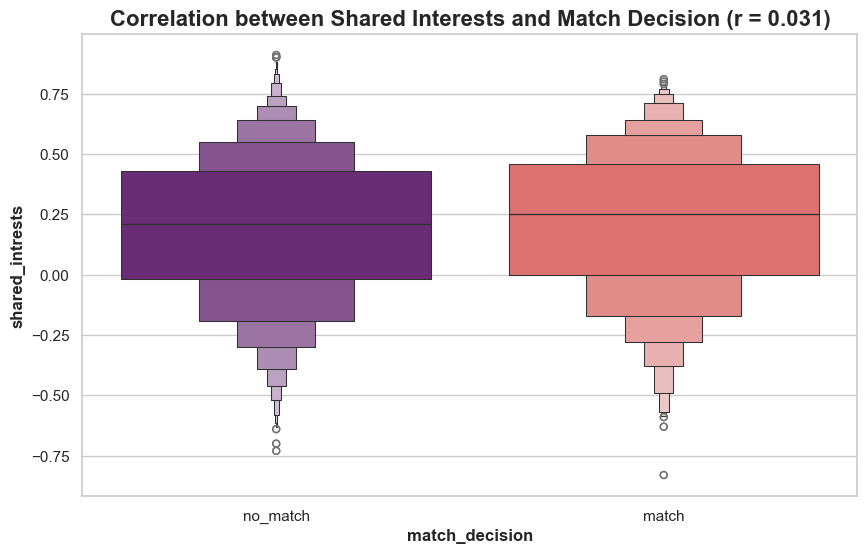

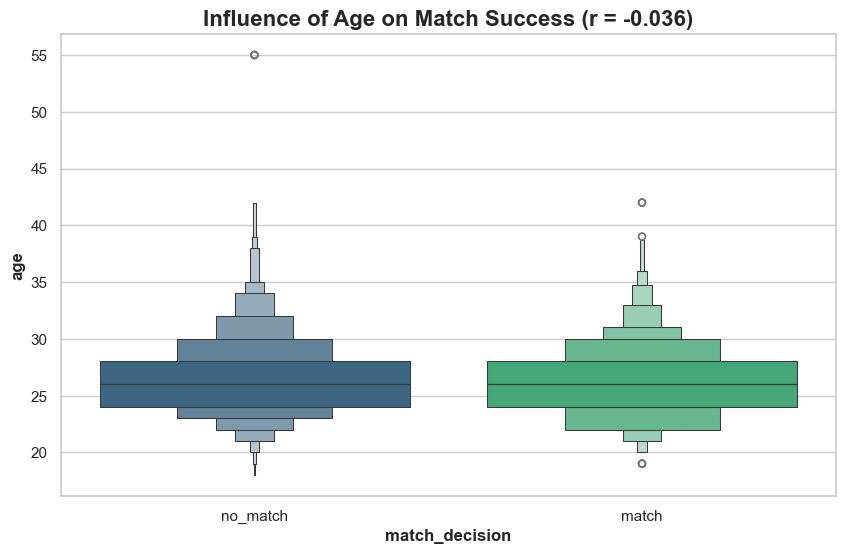

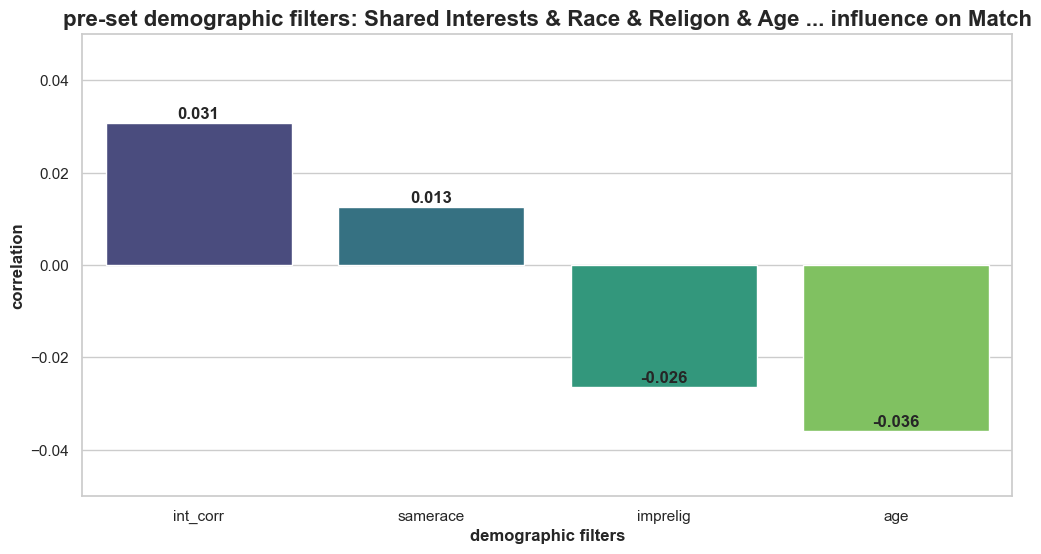

In [107]:
# 1. Data preparation
df_correlations = df_clean[["imprelig", "samerace", "age", "int_corr","match"]].corr()["match"].drop("match").reset_index().sort_values(by="match", ascending=False)
corr_values = df_clean[["imprelig", "samerace", "age", "int_corr", "match"]].corr()["match"]

# 2. Correlation: Interests vs Match
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df_clean, x="match_decision", y="int_corr", palette="magma")
plt.title(f"Correlation between Shared Interests and Match Decision (r = {corr_values["int_corr"]:.3f})", fontweight="bold", fontsize=16)
plt.xlabel(xlabel="match_decision", fontweight="bold", fontsize=12)
plt.ylabel(ylabel="shared_intrests", fontweight="bold", fontsize=12)
plt.show()

# 3. Correlation: Age vs Match
age_match_corr = df_clean['age'].corr(df_clean['match'])

plt.figure(figsize=(10, 6))
sns.boxenplot(data=df_clean, x="match_decision", y="age", palette="viridis")
plt.title(f"Influence of Age on Match Success (r = {corr_values["age"]:.3f})", fontweight="bold", fontsize=16)
plt.xlabel(xlabel="match_decision", fontweight="bold", fontsize=12)
plt.ylabel(ylabel="age", fontweight="bold", fontsize=12)
plt.show()

# 4. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=df_correlations, x=df_correlations["index"], y=df_correlations["match"], palette="viridis")

# 5. Add labels
for i, val in enumerate(df_correlations["match"]):
    plt.text(i, val + 0.001, f'{val:.3f}', ha='center', fontweight='bold')

plt.title("pre-set demographic filters: Shared Interests & Race & Religon & Age ... influence on Match", fontweight="bold", fontsize=16)
plt.ylim(-0.05, 0.05) # Zoom in to see the difference
plt.xlabel(xlabel="demographic filters", fontweight="bold", fontsize=12)
plt.ylabel(ylabel="correlation", fontweight="bold", fontsize=12)
plt.show()

> #### Insights : The Failure of Static Filters
>- *The Ineffectiveness of Demographic Matching:* Factors like Same Race ($r \approx 0.01$) and Religious Importance ($r \approx -0.03$) show virtually zero correlation with the final match decision.
> - *The "Shared Interests" Myth:* Even Interest Correlation—a measure of how much hobbies overlap—has a negligible impact ($r \approx 0.03$). A high score here does not increase the probability of a "Yes," proving that similar interests do not automatically trigger a romantic connection.
>- *Age Neutrality:* Despite common assumptions about age gaps, the correlation remains extremely low ($r \approx -0.04$), indicating that age is not a primary dealbreaker in the heat of a 4-minute encounter.

>- ***Key Takeaway***:   
>Matches are not decided by **"pre-set" demographic filters**. Since these fixed variables fail to explain the outcome, the "*secret sauce*" of attraction must lie in **the subjective evaluations** (Attractiveness, Intelligence, Fun) that occur during the interaction.

### 5.2. The "SAY" Analysis: Declared Preferences
To understand what participants *claim* to look for in a partner, we analyzed the 100-point distribution task.

#### A. Global Hierarchy of Desirability

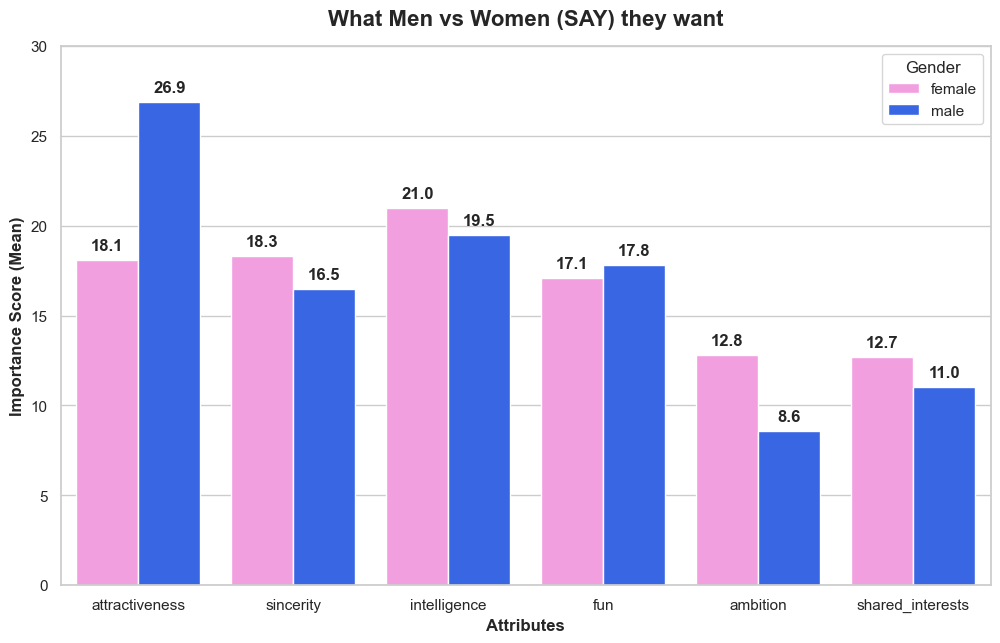

In [108]:
# 1. Create the graphic
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plotting with Seaborn
g = sns.barplot(
    data=df_plot, 
    x="index", 
    y="score", 
    hue="gender", 
    palette={"female": "#FF91E7", "male": "#1D59FF"} # Using your colors
)

# 2. Adding labels on TOP of each bar
for container in g.containers:
    g.bar_label(container, fmt='%.1f', fontweight = "bold", padding=5)

# 3. Aesthetics
plt.title("What Men vs Women (SAY) they want", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Importance Score (Mean)", fontweight="bold", fontsize=12)
plt.xlabel("Attributes", fontweight="bold", fontsize=12)
plt.legend(title="Gender", loc='upper right')
plt.ylim(0, 30) # Give space for the labels and legend

plt.show()

> **Key Observations:**
> * **The Physical Gap**: Men explicitly state that **attractiveness** is their #1 priority ($26.9$), while women rank it below intelligence and sincerity.
> * **The Intelligence Preference**: Women place the highest importance on **intelligence** ($21.0$).
> * **The Ambition Divide**: Women value ambition significantly more than men ($12.8 vs 8.6$), showing a clear difference in long-term partner criteria.
> * **The Consensus on Fun:** Despite the gaps in other areas, both genders rank **Fun** almost identically ($~17.01-17.08%$), showing it as a universal "social currency" in dating.

#### B. The Gender Expectation Gap

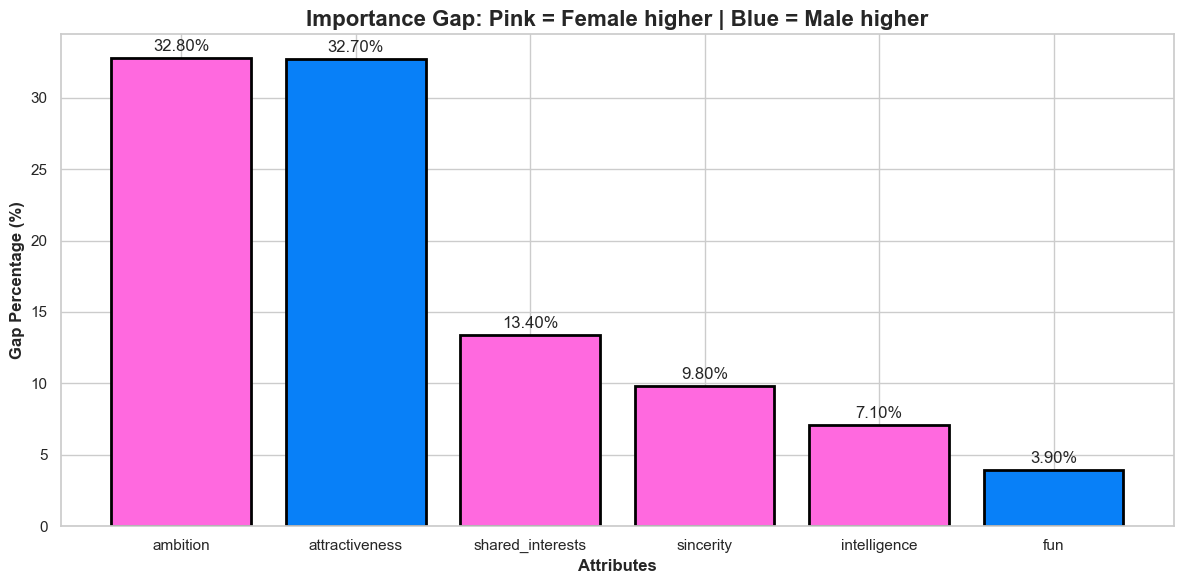

In [110]:
# 1. Create a color list based on "for" column
# We use a list comprehension for efficiency
colors = ["#FF69DF" if gender == "female" else "#0880F8" for gender in df_gap_percentage_sorted["most_important_for"]]

fig, ax = plt.subplots(figsize=(12, 6))

# 2. Apply the color list to your bars
bars = ax.bar(df_gap_percentage_sorted.index, 
              df_gap_percentage_sorted["gap_percentage"].values, 
              width=0.8, 
              edgecolor="black", 
              linewidth=2, 
              color=colors)
   
plt.xlabel("Attributes", fontweight="bold", fontsize=12)
plt.ylabel("Gap Percentage (%)", fontweight="bold", fontsize=12)
plt.title("Importance Gap: Pink = Female higher | Blue = Male higher", fontweight="bold", fontsize=16)

# 3. Add labels
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

> **Insight**:  
>While consensus exists on "Fun," we observe a massive polarization on Ambition (valued by women) and Attractiveness (prioritized by men), with a divergence exceeding 32% for both traits.

>While these gender-specific preferences reveal what participants believe they want in a partner, the critical question remains: 
>- do these stated priorities actually dictate their behavior during the live interaction? 
>- We will now pivot from Stated Intentions (SAY) to Actual Match Decisions (DO) to **uncover the real drivers of attraction**.

### 5.3. Comparing the attractiveness importance vs the match decision (SAY vs DO)
- 5.3.1 What are people's searching for (SAY)?
- 5.3.2 Real match rating depending on the attractiveness
- 5.3.3 What is the real impact of other evaluation criteria ?

#### 5.3.1 What are people's searching for (SAY)?

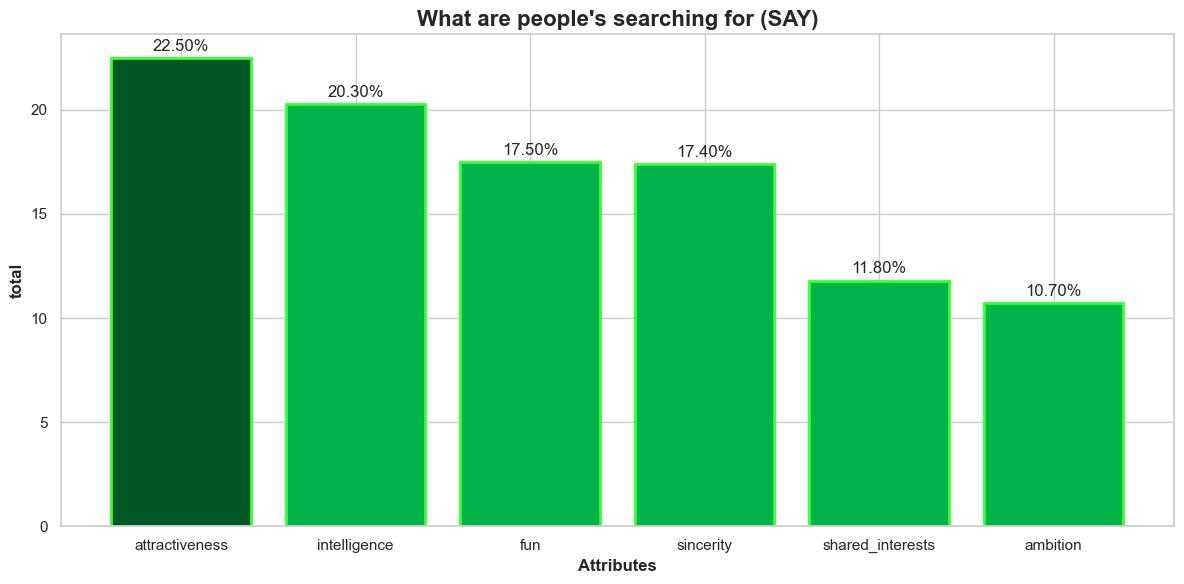

In [111]:
# Creating the figure
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Create a color list: highlight the first bar, others remain green
colors = ["#005624"] + ["#02B349"] * (len(df_gap_total_sorted) - 1)

# 2. Use this list in your bar plot
bars = ax.bar(df_gap_total_sorted.index, 
              df_gap_total_sorted["total"].values, 
              color=colors, # Apply our list
              edgecolor="#36FF36", 
              linewidth=2)

plt.xlabel("Attributes",fontweight="bold", fontsize=12)
plt.ylabel("total", fontweight="bold", fontsize=12)
plt.title("What are people's searching for (SAY)", fontweight="bold", fontsize=16)

# 3. Add labels
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

>**Insights: The Hierarchy of Stated Desires (SAY)**  
>***1. Attractiveness as the Primary Pillar***: Physical attractiveness is ranked as the most important attribute, with an average weight of 22.50%. This confirms that, even before meeting someone, participants consciously prioritize aesthetics.  
>***2. The Intelligence-Sincerity Middle Ground***: Intelligence follows closely at 20.30%, suggesting that participants theoretically value intellectual compatibility almost as much as physical appeal. Together with Fun (17.50%) and Sincerity (17.40%), these four traits form the core of what people claim to look for in a partner.  
>***3. The Devaluation of Ambition***: Ambition is ranked lowest at 10.70%, indicating that in a fast-paced dating environment, long-term professional or personal drive is perceived as less critical than immediate social or physical traits.  
>***4. Balanced Theoretical Expectations***: The relatively small spread between the top four attributes suggests that participants believe they are looking for a "well-rounded" individual rather than focusing on a single dominant trait.
---
> **Now that we have established this relatively balanced "wishlist," let's see if these priorities survive the test of a real encounter.**
---

#### 5.3.2 Real match rating depending on the attractiveness

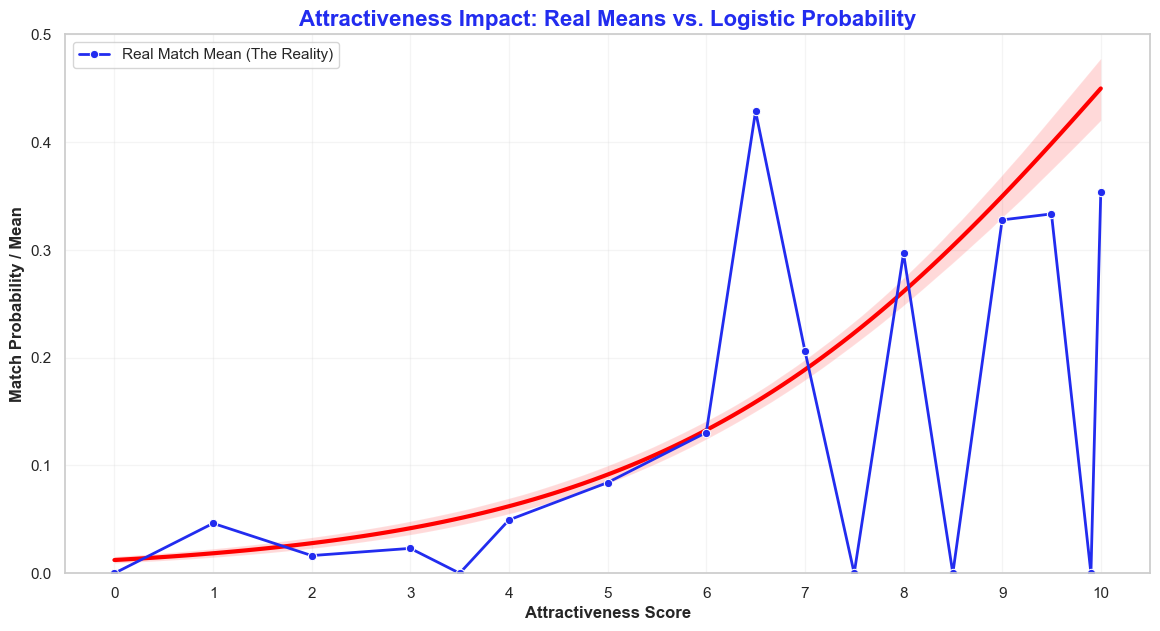

In [112]:
# Preparing the dataframe to get the Real Mean Scores
df_attr = df_clean.groupby("attr")["match"].mean().reset_index()

# 1. Prepare the figure
plt.figure(figsize=(14, 7))

# 2. Layer 1: The Logistic Probability Curve (The S-Curve)
# We use the full df_clean to get the statistical trend
sns.regplot(data=df_clean, 
            x="attr", 
            y="match", 
            logistic=True, 
            scatter=False, # We hide the dots to keep it clean
            line_kws={'color': 'red', 'label': 'Logistic Probability (The Trend)', 'linewidth': 3},
            ax=plt.gca()) # .gca = Get Current Axes, to use only this ax and don't draw any other axes

# 3. Layer 2: The Real Mean Scores (Score Line)
# We use df_attr to show the actual averages
sns.lineplot(data=df_attr, 
             x="attr", 
             y="match", 
             marker='o', 
             color="#222cef", 
             label='Real Match Mean (The Reality)',
             linewidth=2)

# 4. Final Styling
plt.title("Attractiveness Impact: Real Means vs. Logistic Probability", fontweight="bold", fontsize=16, color = "#222cef" )
plt.xlabel("Attractiveness Score", fontweight="bold", fontsize=12)
plt.ylabel("Match Probability / Mean", fontweight="bold", fontsize=12)
plt.xticks(range(0, 11))
plt.ylim(0, 0.5)
plt.grid(True, alpha=0.2)
plt.legend()

plt.show()

>**Insights: Real Match Probability vs. Attractiveness**
>1. **The Attraction Threshold:** The S-Curve (Red) reveals that attractiveness is not linear; match probability remains stagnant until a score of 5, where it enters a "zone of acceleration."
>2. **Model vs. Reality:** The close alignment between the Real Match Mean (Blue) and the logistic trend validates physical appeal as the primary mathematical gatekeeper of success.
>3. **The 40% Probability Ceiling:** Even at a perfect 10/10 rating, the probability of a match peaks at approximately 40%, suggesting that while beauty "opens the door," other factors eventually cap the outcome.

>**Statistical Confidence:** The narrow Pink Shadow *(Confidence Indicator CI)* between scores 6 and 8 indicates high data density and reliability in the most competitive segment of the dating market.

#### 5.3.3 What is the real impact of other evaluation criteria ?

In [113]:
# 1. STATED PREFERENCES (Average score per criterion regardless of gender)
# Creating a dictionary for stated importance: key (criteria) / values (mean score / 100)
importance_stated = {
    "Attractiveness": df_clean["attr1_1"].mean(),
    "Intelligence": df_clean["intel1_1"].mean(),
    "Fun": df_clean["fun1_1"].mean(),
    "Sincerity": df_clean["sinc1_1"].mean(),
    "Shared Interests": df_clean["shar1_1"].mean(),
    "Ambition": df_clean["amb1_1"].mean()
}

# 2. REAL BEHAVIOR (Correlations between partner evaluation and decision)
# Creating a dictionary for correlations: key (criteria) / values (result of each correlation matrix)
correlation_decision = {
    "Attractiveness": df_clean[["attr", "dec"]].corr().iloc[0, 1],
    "Intelligence": df_clean[["intel", "dec"]].corr().iloc[0, 1],
    "Fun": df_clean[["fun", "dec"]].corr().iloc[0, 1],
    "Sincerity": df_clean[["sinc", "dec"]].corr().iloc[0, 1],
    "Shared Interests": df_clean[["shar", "dec"]].corr().iloc[0, 1],
    "Ambition": df_clean[["amb", "dec"]].corr().iloc[0, 1]
}

# 3. Display comparison table: Stated vs. Real impact on decision
comparison = pd.DataFrame({
    "Stated (Mean / 100)": importance_stated,
    "Correlation with Decision (r)": correlation_decision
}).sort_values("Stated (Mean / 100)", ascending=False).round(2)

print("="* 68)
print("Comparison Table:\n")
print(comparison.to_string())
print("=" * 68)

Comparison Table:

                  Stated (Mean / 100)  Correlation with Decision (r)
Attractiveness                  22.50                           0.49
Intelligence                    20.27                           0.22
Fun                             17.46                           0.41
Sincerity                       17.40                           0.21
Shared Interests                11.85                           0.40
Ambition                        10.69                           0.18


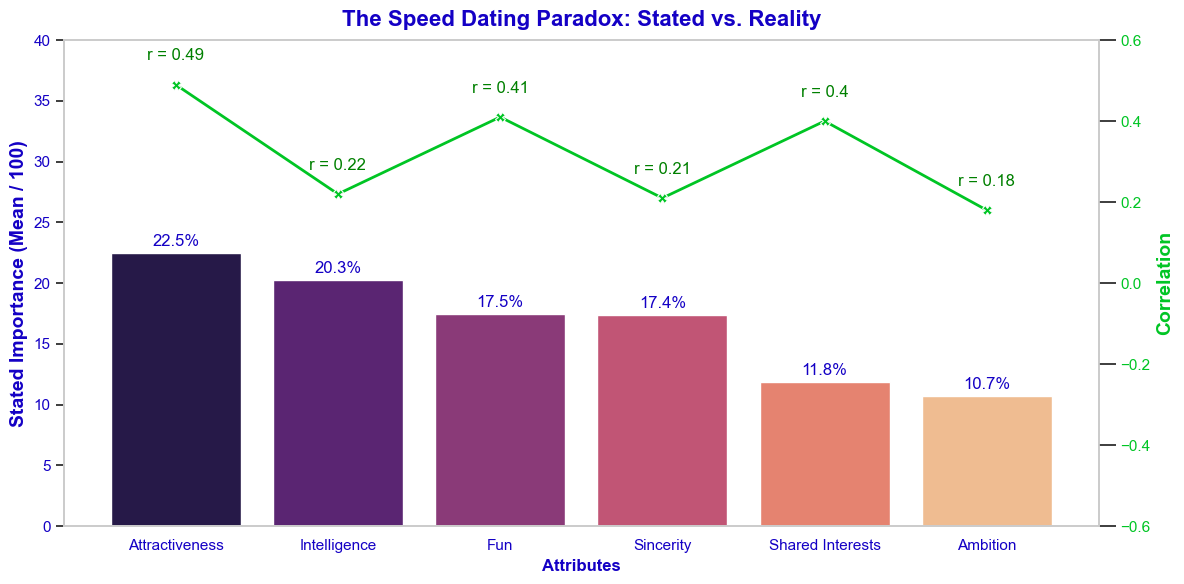

In [114]:
# 4. Visualization of the comparison table
plot_data = comparison.reset_index()
plot_data.columns = ["Attributes", "Stated", "Correlation"]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis (Bars for Stated Importances) 
sns.barplot(x="Attributes", y="Stated", data=plot_data, ax=ax1, palette="magma")
ax1.set_ylabel("Stated Importance (Mean / 100)", fontsize=14, fontweight="bold", color="#1400C5")
ax1.set_ylim(0, 40) 
ax1.tick_params(axis="x", labelcolor="#1400C5")
ax1.tick_params(axis="y", labelcolor="#1400C5")

# Display labels on all bars
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%", padding=3, fontsize=12, color="#1400C5")

# - Secondary Axis (Line for Correlation) ---
ax2 = ax1.twinx()  # Create secondary axis sharing the same X-axis
sns.lineplot(x="Attributes", y="Correlation", data=plot_data, ax=ax2, color="#00C524", marker="X", linewidth=2, markersize=7)

# Remove title and hide right-side axis labels to keep the graph clean
ax2.set_ylabel("Correlation", fontsize=14, fontweight="bold", color="#00C524")
ax2.set_ylim(-0.6, 0.6) 
ax2.tick_params(axis="y", labelcolor="#00C524", size=12)
ax2.spines["left"].set_visible(True) 

# - Title and finishing touches ---
plt.title("The Speed Dating Paradox: Stated vs. Reality", fontsize=16, fontweight="bold", color= "#1400C5", pad=10)
ax1.set_xlabel("Attributes", fontweight="bold", fontsize=12, color= "#1400C5")
ax1.grid(False)
ax2.grid(False)

# Add correlation values above points for readability
for i, row in plot_data.iterrows():
    ax2.text(i, row["Correlation"] + 0.06, f"r = {row['Correlation']}", color="green", ha="center", fontsize=12)

plt.tight_layout()
plt.show()

>**Insights: The Paradox of Choice**  
>- *The Rationality Gap:* While participants rank **Intelligence** as a top-tier priority (20.3), its actual correlation with the final decision is significantly lower than that of **Attractiveness**.
>- *The True Driver:* **Attractiveness** shows the strongest correlation with a "Yes" ($r = 0.52$), confirming it is **the primary engine** of the match, regardless of what participants claim initially.
>- *The Shared Interests Myth:* Although participants claim to value common ground, the actual impact on the final decision is weak ($r = 0.21$), proving chemistry overrides hobbies.
>- *Ambition's Negligible Role:* Ambition remains the least influential factor in both theory and practice, having almost no impact on the final outcome.

### 5.4. Can people accurately predict their own perceived value in the dating market?

#### The whole dates statistics 

In [115]:
# Map attribute names for consistency in the perception analysis
labels_perception = {
    "attr3_1": "attractiveness",
    "sinc3_1": "sincerity",
    "intel3_1": "intelligence",
    "fun3_1": "fun",
    "amb3_1": "ambition"
}

In [116]:
# 1. Extract mean values for self-evaluation and partner ratings
# These values are retrieved from the pre-defined column lists
self_evaluation_mean = df_clean[personal_self_evaluation].mean().values
patrners_evaluation_mean = df_clean[partners_score_card_notes].mean().values

# 2. Build a summary DataFrame for perception comparison
df_total_perception = pd.DataFrame(index=labels_perception.values())
df_total_perception["self_evaluation_mean"] = self_evaluation_mean
df_total_perception["patrners_evaluation_mean"] = patrners_evaluation_mean

# 3. Calculate the gap (Difference between Self and Partner perception)
df_total_perception["differnce"] = (df_total_perception["self_evaluation_mean"] - 
                                    df_total_perception["patrners_evaluation_mean"])

# 4. Categorize based on the gap direction (Over-estimation vs Under-estimation)
# 'Arrogant' implies over-confidence, 'Modeste' implies under-rating oneself
df_total_perception["evaluation"] = np.where(df_total_perception["differnce"] > 0, "arrogant", "modeste")

df_total_perception

,self_evaluation_mean,patrners_evaluation_mean,differnce,evaluation
attractiveness,7.084352,6.190411,0.893940,arrogant
sincerity,8.295776,7.175256,1.120520,arrogant
intelligence,8.404454,7.369301,1.035152,arrogant
fun,7.704345,6.400599,1.303746,arrogant
ambition,7.577877,6.778409,0.799468,arrogant


In [117]:
# Calculate the average global gap to determine the general trend
avg_gap = df_total_perception["differnce"].mean()
perception_trend = "over-estimate" if avg_gap > 0 else "under-estimate"

print(f"On average, participants {perception_trend} their value by {abs(avg_gap):.2f} points "
      "compared to their partner's ratings.")

On average, participants over-estimate their value by 1.03 points compared to their partner's ratings.


#### Radar Chart Visualization

In [118]:
# 1. Prepare data (Closing the loop for the radar chart)
categories = list(df_total_perception.index)
# We repeat the first value at the end to close the circular line
self_eval = list(df_total_perception["self_evaluation_mean"])
self_eval += [self_eval[0]]
partners_eval = list(df_total_perception["patrners_evaluation_mean"])
partners_eval += [partners_eval[0]]
categories_closed = categories + [categories[0]]

# 2. Create the Figure
fig = go.Figure()

# Trace for Self-Evaluation
fig.add_trace(go.Scatterpolar(
      r=self_eval,
      theta=categories_closed,
      fill="toself",
      name="Self-Evaluation",
      line_color="#005624"
))

# Trace for Partners-Evaluation
fig.add_trace(go.Scatterpolar(
      r=partners_eval,
      theta=categories_closed,
      fill="toself",
      name="Partners Evaluation",
      line_color="#FF91E7"
))

# 3. Final Styling
fig.update_layout(
  polar=dict(
    radialaxis=dict(visible=True, 
                    range=[0, max(self_eval, partners_eval)])),
  showlegend=True,
  title="Self-Perception vs. Partner's Reality Check"
)

fig.show()

>**Insights: The Confidence Gap**
>- *The Universal Over-Estimation:* On average, participants over-estimate their own social value by $0.70$ points compared to the ratings given by their partners.
>- *Subjective Bias:* The gap is most visible in traits like **Intelligence** and **Sincerity**, where self-rating is significantly higher than partner perception, suggesting that these "internal" traits are the hardest to judge objectively.
>- *The Alignment on Ambition:* Ambition shows the smallest gap, indicating that professional drive is perhaps more easily and accurately communicated during a short encounter.
>- *Psychological Narrative:* This "superiority bias" explains why many participants might feel they are "out of someone's league" or why they might be surprised by a lack of matches despite having high self-confidence.

## 🏁 Final Conclusion: The Speed Dating Paradox

This project provided a comprehensive data-driven journey into the mechanics of human attraction, moving from raw data preparation to psychological insights. By confronting what participants **say** they want with what they actually **do**, I unraveled the "Rationality Gap" inherent in romantic decision-making.

### 1. The "Say vs. Do" Disconnect
While participants officially claim to seek a balanced mix of attributes (Intelligence, Sincerity, and Fun), the **"Reality Check"** proves otherwise. Physical Attractiveness remains the primary engine of the dating market. We observed that while participants *say* attractiveness represents only **22.5%** of their choice, the data shows it acts as a **binary gatekeeper**: a score below 6/10 almost mathematically guarantees a rejection, regardless of other qualities.

### 2. The Myth of Surface Compatibility
- One of the most striking findings is the negligible impact of traditional "rational" criteria.
- * **Shared Interests** ($r \approx 0.03$), **Same Religion** ($r \approx -0.03$), **Age** ($r \approx -0.04$) and **Same Race** ($r \approx 0.01$) showed near-zero correlation with actual matches.
- This suggests that in a high-pressure, fast-paced environment, visceral chemistry consistently overrides pre-conceived sociological filters.

### 3. The Perception Bubble
Our analysis of self-perception revealed a consistent **Positive Self-Perception Bias**. On average, participants over-estimate their own social value by approximately **0.70 points** compared to the objective ratings from their partners. This "**Confidence Gap**" is particularly visible in subjective traits like Intelligence and Ambition.

### 4. Technical Takeaway

Beyond the sociological insights, this notebook demonstrates a robust end-to-end Data Science workflow:

* **Data Integrity**: Successful handling of relational gaps (Wave 5, missing IDs).
* **Feature Engineering**: 
- Wave 5 ID Recovery: Implemented a logic to recover missing relational IDs, ensuring the integrity of interactions that would otherwise have been lost. 
- Transforming raw scores into meaningful categorical labels and comparative "Gaps".
* **Advanced Visualization**: Using distribution plots, heatmaps, and Radar Charts to translate complex statistics into actionable storytelling.

---

> **Final Insight**:  
>- Speed dating is not a rational marketplace where people find their "match" based on a checklist. 
>- It is an environment where **physical appeal opens the door**, and where we are significantly more critical of others than we are of ourselves.